## Dataset Information
The data used in this project is the **NIPS Papers (1987-2019)** dataset, which contains the full text of all papers published at the Neural Information Processing Systems (NeurIPS) conference over three decades.

**Source:** [Kaggle - NIPS Papers 1987-2019 (Updated)](https://www.kaggle.com/datasets/rowhitswami/nips-papers-1987-2019-updated?select=papers.csv)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 5)

papers = pd.read_csv('../data/papers.csv')

In [3]:
papers.head()

,source_id,year,title,abstract,full_text
0,27,1987,Bit-Serial Neural Networks,NaN,573 \n\nBIT - SERIAL NEURAL NETWORKS \n\nAlan...
1,63,1987,Connectivity Versus Entropy,NaN,1 \n\nCONNECTIVITY VERSUS ENTROPY \n\nYaser S...
2,60,1987,The Hopfield Model with Multi-Level Neurons,NaN,278 \n\nTHE HOPFIELD MODEL WITH MUL TI-LEVEL N...
3,59,1987,How Neural Nets Work,NaN,442 \n\nAlan Lapedes \nRobert Farber \n\nThe...
4,69,1987,Spatial Organization of Neural Networks: A Pro...,NaN,740 \n\nSPATIAL ORGANIZATION OF NEURAL NEn...


In [4]:
papers.info()

<class 'pandas.DataFrame'>
RangeIndex: 9680 entries, 0 to 9679
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   source_id  9680 non-null   int64
 1   year       9680 non-null   int64
 2   title      9680 non-null   str  
 3   abstract   6361 non-null   str  
 4   full_text  9677 non-null   str  
dtypes: int64(2), str(3)
memory usage: 309.8 MB


In [5]:
print(papers.isnull().sum())

source_id       0
year            0
title           0
abstract     3319
full_text       3
dtype: int64


In [6]:
papers.dropna(subset=['full_text'], inplace=True)
papers.reset_index(drop=True, inplace=True)

In [7]:
print(papers.duplicated(subset=['full_text']).sum())

4


In [8]:
papers.drop_duplicates(subset=['full_text'], inplace=True)
papers.reset_index(drop=True, inplace=True)

## Analyzing Trends

C:\Users\Reem\AppData\Local\Temp\ipykernel_10828\1179297362.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=paper_counts.index, y=paper_counts.values, alpha=0.5, palette='Blues_d', ax=ax1)


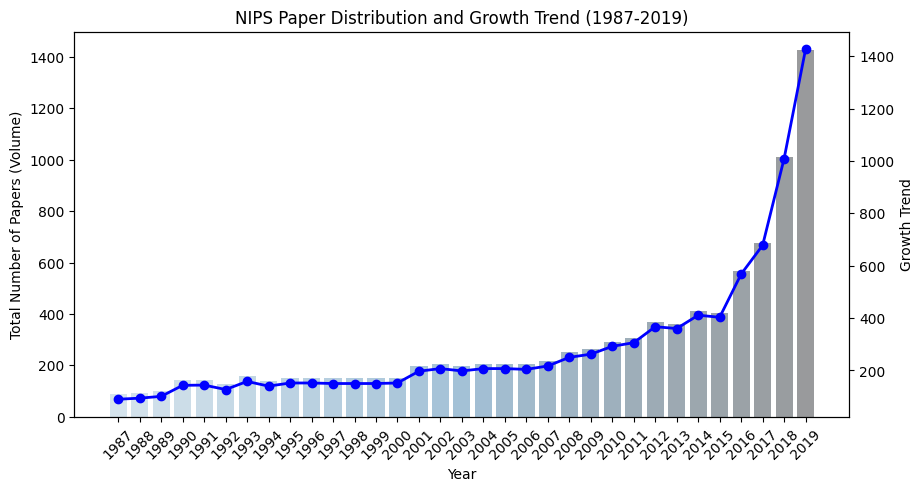

Total Papers after cleaning: 9673


In [9]:
paper_counts = papers['year'].value_counts().sort_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(x=paper_counts.index, y=paper_counts.values, alpha=0.5, palette='Blues_d', ax=ax1)
ax1.set_ylabel('Total Number of Papers (Volume)')
ax1.set_xlabel('Year')
plt.xticks(rotation=45)

ax2 = ax1.twinx() 
ax2.plot(range(len(paper_counts)), paper_counts.values, color='blue', marker='o', linewidth=2)
ax2.set_ylabel('Growth Trend')

plt.title('NIPS Paper Distribution and Growth Trend (1987-2019)')
plt.show()

print(f"Total Papers after cleaning: {len(papers)}")

## Correlation Analysis

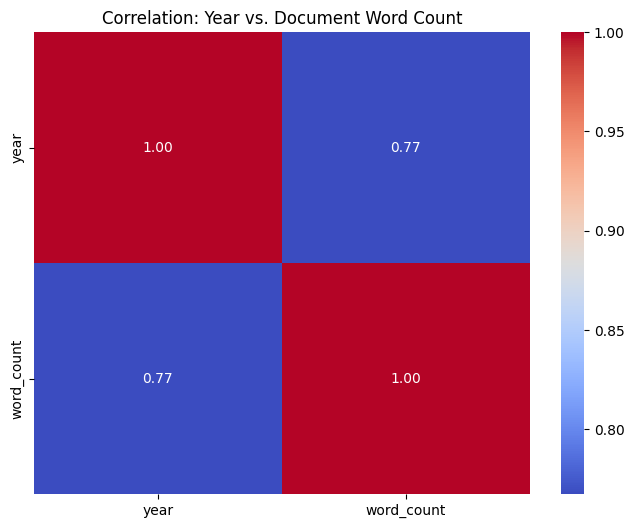

In [10]:
papers['word_count'] = papers['full_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 6))
corr_matrix = papers[['year', 'word_count']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Year vs. Document Word Count')
plt.show()

## Document Length Outlier Detection

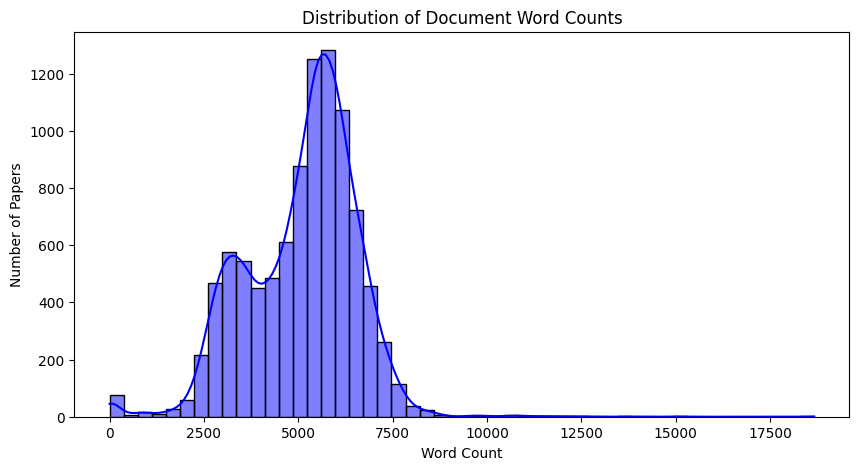

Found 66 papers with fewer than 100 words.


In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(papers['word_count'], bins=50, kde=True, color='blue')
plt.title('Distribution of Document Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Number of Papers')
plt.show()

short_papers = papers[papers['word_count'] < 100]
print(f"Found {len(short_papers)} papers with fewer than 100 words.")

In [12]:
papers = papers[papers['word_count'] >= 100]
papers.reset_index(drop=True, inplace=True)
print(f"Papers remaining after filtering: {len(papers)}")

Papers remaining after filtering: 9607


## Keyword Frequency Analysis

C:\Users\Reem\AppData\Local\Temp\ipykernel_10828\3085724137.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_words_freq, palette='Blues_d')


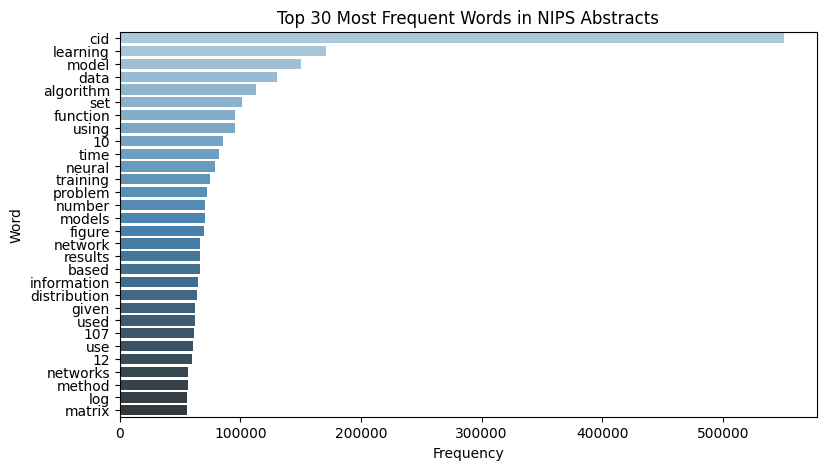

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words='english', max_features=100)
word_counts = vec.fit_transform(papers['full_text'])
sum_words = word_counts.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# Plotting the top 20 words
df_words_freq = pd.DataFrame(words_freq[:30], columns=['Word', 'Frequency'])
sns.barplot(x='Frequency', y='Word', data=df_words_freq, palette='Blues_d')
plt.title('Top 30 Most Frequent Words in NIPS Abstracts')
plt.show()

- The frequency plot reveals that the standard 'english' stop words list is insufficient for this specific dataset.
- Several high-frequency terms still appear that are irrelevant to the core

## N-Gram Analysis (Detecting Phrases)

C:\Users\Reem\AppData\Local\Temp\ipykernel_10828\2431285908.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Phrase', data=df_bigrams, palette='Blues_d')


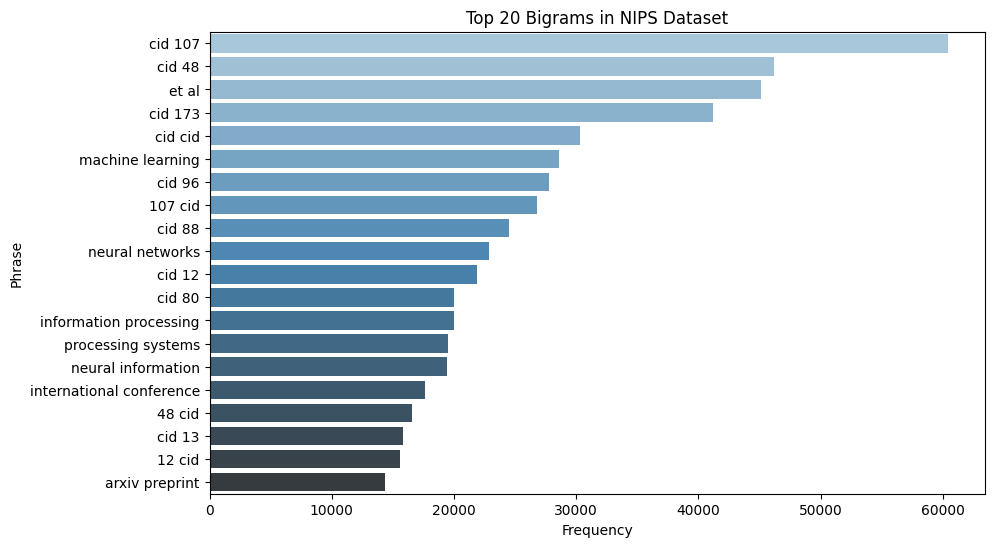

In [14]:
vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=20)
bigrams = vec.fit_transform(papers['full_text'])
sum_bigrams = bigrams.sum(axis=0)
bigram_freq = [(word, sum_bigrams[0, idx]) for word, idx in vec.vocabulary_.items()]
bigram_freq = sorted(bigram_freq, key=lambda x: x[1], reverse=True)

df_bigrams = pd.DataFrame(bigram_freq, columns=['Phrase', 'Frequency'])
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Phrase', data=df_bigrams, palette='Blues_d')
plt.title('Top 20 Bigrams in NIPS Dataset')
plt.show()

## Advanced Academic Text Cleaning (Regex)

In [15]:
import re

def advanced_academic_cleaning(text):
    if not isinstance(text, str):
        return ""
    
    text = re.sub(r'\S+@\S+', '', text) 
    text = re.sub(r'http\S+', '', text) 
    
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)
    
    text = re.sub(r'cid:\d+', ' ', text)
    text = re.sub(r'\bcid\b', ' ', text)
    
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    
    text = re.sub(r'\d+', ' ', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

papers['full_text'] = papers['full_text'].apply(advanced_academic_cleaning)

In [16]:
# Lowercase
papers['full_text'] = papers['full_text'].str.lower()

# Remove punctuation
papers['full_text'] = papers['full_text'].apply(lambda x: re.sub(r'[^\w\s]', '', x) if isinstance(x, str) else x)

## Tokenization

In [17]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Reem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Reem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Reem\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
from nltk.tokenize import word_tokenize

papers['tokens'] = papers['full_text'].apply(lambda x: word_tokenize(x) if isinstance(x, str) else [])

## Zipf's Law Verification

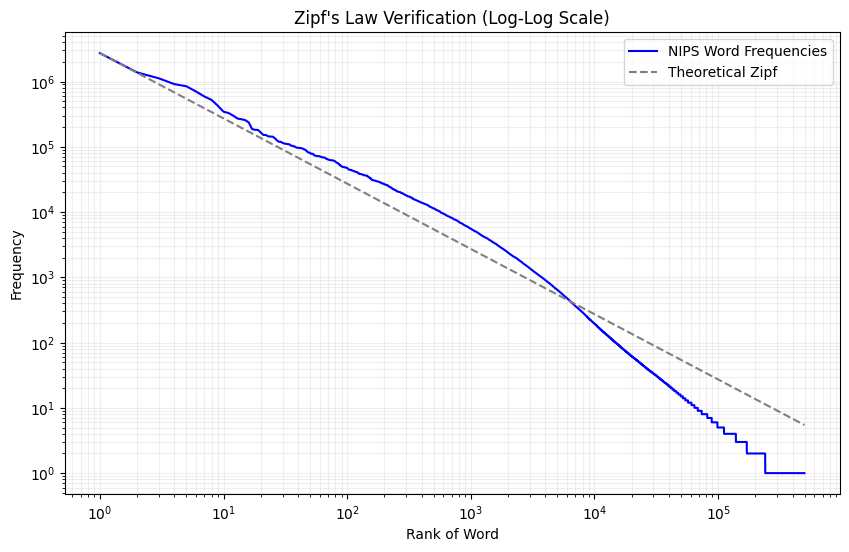

In [19]:
from nltk.probability import FreqDist

all_tokens = [token for sublist in papers['tokens'] for token in sublist]
fdist = FreqDist(all_tokens)

counts = np.array(sorted(fdist.values(), reverse=True))
ranks = np.arange(1, len(counts) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(ranks, counts, label="NIPS Word Frequencies", color='blue')
plt.loglog(ranks, counts[0]/ranks, linestyle='--', color='gray', label="Theoretical Zipf")

plt.title("Zipf's Law Verification (Log-Log Scale)")
plt.xlabel('Rank of Word')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## Stopwords removal

In [20]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [21]:
# Define custom stopwords for NIPS context
custom_stopwords = {"cid", "data", 
                    "set", "problem", "models", "number", "figure", "results",
                    "using", "used", "use", "given","networks",
                    }

def remove_stopwords(tokens):
    return [token for token in tokens if token.lower() not in stop_words and 
            token.lower() not in custom_stopwords and not token.isdigit()]  

papers['filtered_tokens'] = papers['tokens'].apply(remove_stopwords)

## Lemmatization
- reduces words to their base or root form

In [22]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Reem\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Reem\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Reem\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Reem\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [23]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    tagged = nltk.pos_tag(tokens)
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return [lemmatizer.lemmatize(word, tag_dict.get(tag[0].upper(), wordnet.NOUN)) 
            for word, tag in tagged]

papers['lemmatized_tokens'] = papers['filtered_tokens'].apply(lemmatize_tokens)

In [24]:
extra_noise = {'eqn', 'nl', 'en', 'po', 'fig', 'table', 'result', "cid", "data",
                "set", "problem", "models", "number", "figure", "results",
                "using", "used", "use", "given", "networks", 'thus', 'etal',
                'however', 'instance', 'essentially', 'also', 'therefore', 'show', 
                'propose', 'approach', 'method', 'case', 'hand', 'called', 
                'typically', 'typically', 'one'}

allowed_short_words = {'ai', 'ml'}

def refine_tokens_final(tokens):
    cleaned = []
    for t in tokens:
        t = t.replace('-', '').replace('_', '')
        
        split_done = False
        for glue in ['and', 'with', 'for', 'the', 'is']:
            if glue in t and t != glue:
                parts = t.split(glue)
                if len(parts[0]) > 3 and parts[0] not in extra_noise:
                    cleaned.append(parts[0])
                    split_done = True
                    break  
        if split_done: continue  

        if t not in extra_noise and (len(t) >= 3 or t in allowed_short_words):
            cleaned.append(t)
    return cleaned

papers['lemmatized_tokens'] = papers['lemmatized_tokens'].apply(refine_tokens_final)

## Phrase Detection and Bigram Modeling

In [25]:
from gensim.models.phrases import Phrases, Phraser
phrases = Phrases(papers['lemmatized_tokens'], min_count=5, threshold=10)
bigram_model = Phraser(phrases)
papers['lemmatized_tokens'] = list(bigram_model[papers['lemmatized_tokens']])

In [26]:
import os
os.makedirs('../models', exist_ok=True)

bigram_model.save('../models/bigram_model.pkl')
print("Bigram model saved to ../models/bigram_model.pkl")

Bigram model saved to ../models/bigram_model.pkl


Before/After token count

In [27]:
avg_before = papers['tokens'].apply(len).mean()
avg_after = papers['lemmatized_tokens'].apply(len).mean()
print(f"Avg tokens before cleaning: {avg_before:.0f}")
print(f"Avg tokens after cleaning:  {avg_after:.0f}")
print(f"Reduction: {(1 - avg_after/avg_before)*100:.1f}%")

Avg tokens before cleaning: 4458
Avg tokens after cleaning:  2013
Reduction: 54.8%


Saving Preprocessed Data

In [28]:
papers.to_csv('../data/papers_preprocessed.csv', index=False)